<a href="https://colab.research.google.com/github/JeyasuriyaJ/jeyasuriya-codeboosters-2026/blob/main/Day-3/Day_3_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
API_KEY = 'd897748217471fea736fd3b3c26834c2'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = ['Mumbai','Delhi','Bangalore','Chennai',
             'Hyderabad','Kolkata','Pune','Jaipur','Coimbatore']

print(f'API configured for {len(CITIES)} cities')
print(f'Cities{CITIES}')
print('\nImportant : Replace YOUR_API_KEY with your actual key before running')

API configured for 9 cities
Cities['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur', 'Coimbatore']

Important : Replace YOUR_API_KEY with your actual key before running


In [19]:
import requests

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error


print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')

CALLING weather API..
Fetching:Mumbai...34.0C, Haze
Fetching:Delhi...44.0C, Clear
Fetching:Bangalore...29.8C, Clouds
Fetching:Chennai...36.2C, Clouds
Fetching:Hyderabad...30.2C, Clouds
Fetching:Kolkata...32.0C, Haze
Fetching:Pune...36.9C, Clouds
Fetching:Jaipur...42.6C, Haze
Fetching:Coimbatore...33.9C, Clouds

Successfully fetched:9/9 cities


CALLING weather API..
Fetching:Mumbai...34.0C, Haze
Fetching:Delhi...44.0C, Clear
Fetching:Bangalore...29.7C, Clouds
Fetching:Chennai...35.6C, Clouds
Fetching:Hyderabad...31.2C, Clouds
Fetching:Kolkata...32.0C, Haze
Fetching:Pune...36.3C, Clouds
Fetching:Jaipur...42.6C, Haze
Fetching:Coimbatore...33.9C, Clouds

Successfully fetched:9/9 cities


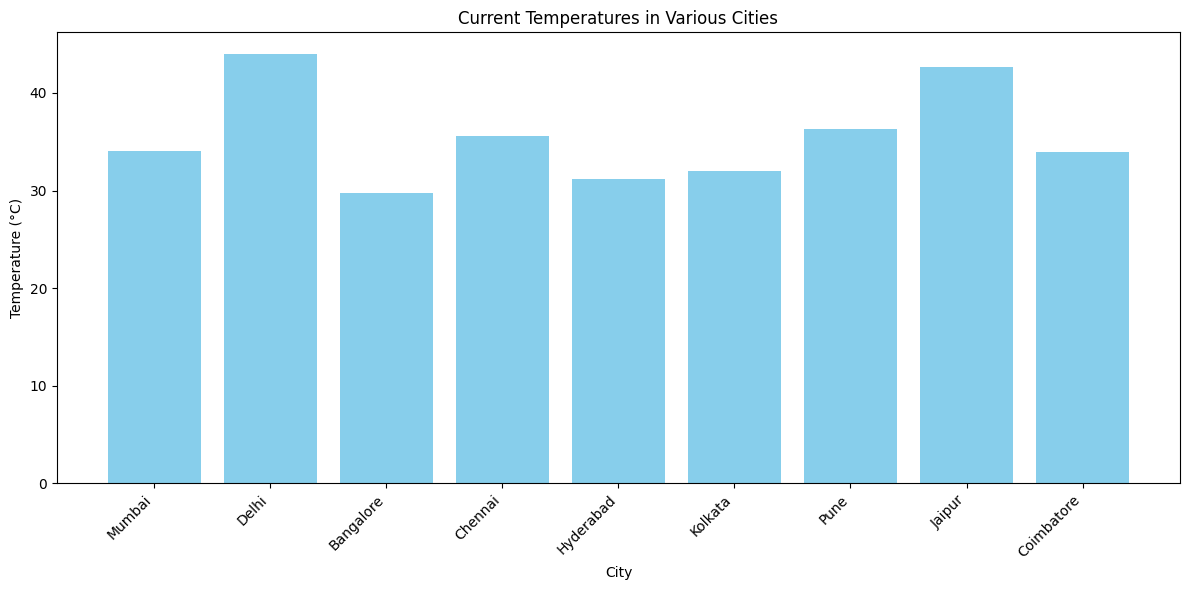


Weather Data Table:
         city  temperature  feels_like  humidity  pressure  wind_speed  \
0      Mumbai         34.0        41.0        59      1009        6.17   
1       Delhi         44.0        41.1        10       999        5.14   
2   Bangalore         29.7        31.4        55      1010        6.71   
3     Chennai         35.6        42.6        55      1005        0.89   
4   Hyderabad         31.2        33.2        51      1008        8.75   
5     Kolkata         32.0        38.9        66      1001        3.60   
6        Pune         36.3        35.7        26      1008        3.76   
7      Jaipur         42.6        40.9        14      1001        5.66   
8  Coimbatore         33.9        38.8        52      1008        6.17   

  condition  visibility  
0      Haze        7000  
1     Clear        7000  
2    Clouds        8000  
3    Clouds       10000  
4    Clouds        6000  
5      Haze        5000  
6    Clouds       10000  
7      Haze        5000  
8   

In [21]:
import requests
import matplotlib.pyplot as plt
import pandas as pd

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'humidity':data['main']['humidity'], # Added humidity
          'pressure':data['main']['pressure'], # Added pressure
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error


print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')

# Create a Matplotlib project

# Extract data for plotting
cities_plot = [record['city'] for record in weather_records]
temperatures_plot = [record['temperature'] for record in weather_records]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(cities_plot, temperatures_plot, color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Current Temperatures in Various Cities')
plt.xticks(rotation=45, ha='right') # Rotate city names for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Display data using pandas
df_weather = pd.DataFrame(weather_records)
print("\nWeather Data Table:")
print(df_weather[['city', 'temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'condition', 'visibility']])